# CE49X: Introduction to Computational Thinking and Data Science for Civil Engineers
## Week 5: Statistical Analysis I

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

Based on *Python Data Science Handbook* by Jake VanderPlas and supplementary statistics materials

---

Core Topics in Descriptive Statistics, Probability, and Distributions

### Topics Covered:
1. Descriptive Statistics
2. Probability Review
3. Discrete Random Variables and Distributions
4. Expectation and Variance Concepts
5. Continuous Random Variables and Distributions
6. Moments and Summary Measures
7. Conclusion and Summary

In [35]:
# Setup: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
%matplotlib inline

print(f"NumPy version: {np.__version__}")
print(f"SciPy version: {scipy.__version__}")

NumPy version: 2.3.5
SciPy version: 1.16.3


---
## 1. Descriptive Statistics

### What is Descriptive Statistics?

Descriptive statistics are methods for **summarizing and describing** the main features of a dataset.

**Key Components:**
- **Central Tendency**: Where is the "center" of the data? (Mean, Median, Mode)
- **Spread / Variability**: How spread out is the data? (Range, Variance, Standard Deviation, IQR)
- **Shape**: Is the distribution symmetric? Skewed? Heavy-tailed? (Skewness, Kurtosis)
- **Visualization**: Histograms, boxplots, density plots

> **Key Insight: Engineering Context**
> Descriptive statistics are essential for analyzing material strengths, load measurements, environmental data, and experimental results in civil engineering. Before applying any advanced model, you must first **understand your data**.

### Measures of Central Tendency

Central tendency describes the "typical" or "central" value of a dataset.

**Mean (Arithmetic Average):**

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

- The sum of all values divided by the number of values
- Sensitive to outliers

**Median:**
- The middle value when data is ordered from smallest to largest
- Robust to outliers
- For even $n$: average of the two middle values

**Mode:**
- The most frequently occurring value
- Can have multiple modes (bimodal, multimodal)
- Most useful for categorical data

In [6]:
import numpy as np
from scipy import stats

# Concrete compressive strength data (MPa)
strengths = np.array([28.5, 31.2, 29.8, 35.1, 30.4, 27.9, 32.5, 29.1, 
                      33.7, 28.3, 30.8, 31.5, 29.6, 34.2, 27.5])

# Measures of central tendency
mean_val = np.mean(strengths)
median_val = np.median(strengths)
mode_result = stats.mode(strengths, keepdims=True)

print(f"Mean: {mean_val:.2f} MPa")
print(f"Median: {median_val:.2f} MPa")
print(f"Mode: {mode_result.mode[0]:.2f} MPa")

Mean: 30.67 MPa
Median: 30.40 MPa
Mode: 27.50 MPa


> **Key Insight: When to Use Which?**
> - **Mean**: Best for symmetric distributions without outliers
> - **Median**: Best for skewed data or data with outliers
> - **Mode**: Best for categorical data or finding the most common value
>
> In a **right-skewed** distribution: Mode < Median < Mean  
> In a **left-skewed** distribution: Mean < Median < Mode

### Measures of Spread (Variability)

Spread measures tell us how dispersed the data values are around the center.

**Range:**
$$R = x_{\max} - x_{\min}$$

**Sample Variance:**
$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

Note: We use $n-1$ (Bessel's correction) for the **sample** variance to get an unbiased estimator.

**Standard Deviation:**
$$s = \sqrt{s^2}$$

**Interquartile Range (IQR):**
$$\text{IQR} = Q_3 - Q_1$$

where $Q_1$ is the 25th percentile and $Q_3$ is the 75th percentile.

In [7]:
# Measures of spread
range_val = np.ptp(strengths)  # peak to peak
variance = np.var(strengths, ddof=1)  # sample variance
std_dev = np.std(strengths, ddof=1)
q1, q3 = np.percentile(strengths, [25, 75])
iqr = q3 - q1

print(f"Range: {range_val:.2f} MPa")
print(f"Variance: {variance:.2f} MPa\u00b2")
print(f"Standard Deviation: {std_dev:.2f} MPa")
print(f"Q1: {q1:.2f}, Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f} MPa")

Range: 7.60 MPa
Variance: 5.58 MPa²
Standard Deviation: 2.36 MPa
Q1: 28.80, Q3: 32.00
IQR: 3.20 MPa


### Quantiles and Five-Number Summary

The **five-number summary** provides a quick overview of data distribution:
- Minimum
- First Quartile ($Q_1$, 25th percentile)
- Median ($Q_2$, 50th percentile)
- Third Quartile ($Q_3$, 75th percentile)
- Maximum

In [8]:
# Five-number summary
five_num = np.percentile(strengths, [0, 25, 50, 75, 100])
print(f"Min: {five_num[0]:.2f}")
print(f"Q1: {five_num[1]:.2f}")
print(f"Median: {five_num[2]:.2f}")
print(f"Q3: {five_num[3]:.2f}")
print(f"Max: {five_num[4]:.2f}")

Min: 27.50
Q1: 28.80
Median: 30.40
Q3: 32.00
Max: 35.10


### Shape Measures: Skewness and Kurtosis

**Skewness** measures the asymmetry of the distribution:

$$\text{Skewness} = \frac{E[(X-\mu)^3]}{\sigma^3}$$

- Skewness = 0: Symmetric
- Skewness > 0: Right-skewed (tail extends to the right)
- Skewness < 0: Left-skewed (tail extends to the left)

**Kurtosis** measures the "tailedness" of the distribution:

$$\text{Kurtosis} = \frac{E[(X-\mu)^4]}{\sigma^4}$$

- Excess Kurtosis = Kurtosis $- 3$ (Normal distribution has excess kurtosis = 0)
- Leptokurtic (excess kurtosis > 0): Heavy tails
- Platykurtic (excess kurtosis < 0): Light tails

In [9]:
from scipy import stats

skewness = stats.skew(strengths)
kurtosis = stats.kurtosis(strengths)  # excess kurtosis (Normal = 0)

print(f"Skewness: {skewness:.4f}")
print(f"Excess Kurtosis: {kurtosis:.4f}")

Skewness: 0.4625
Excess Kurtosis: -0.8921


### Data Visualization: Histograms and Boxplots

Visualization is an essential part of descriptive statistics. Two key plots:
- **Histogram**: Shows the frequency distribution of data
- **Boxplot**: Displays the five-number summary visually, highlighting outliers

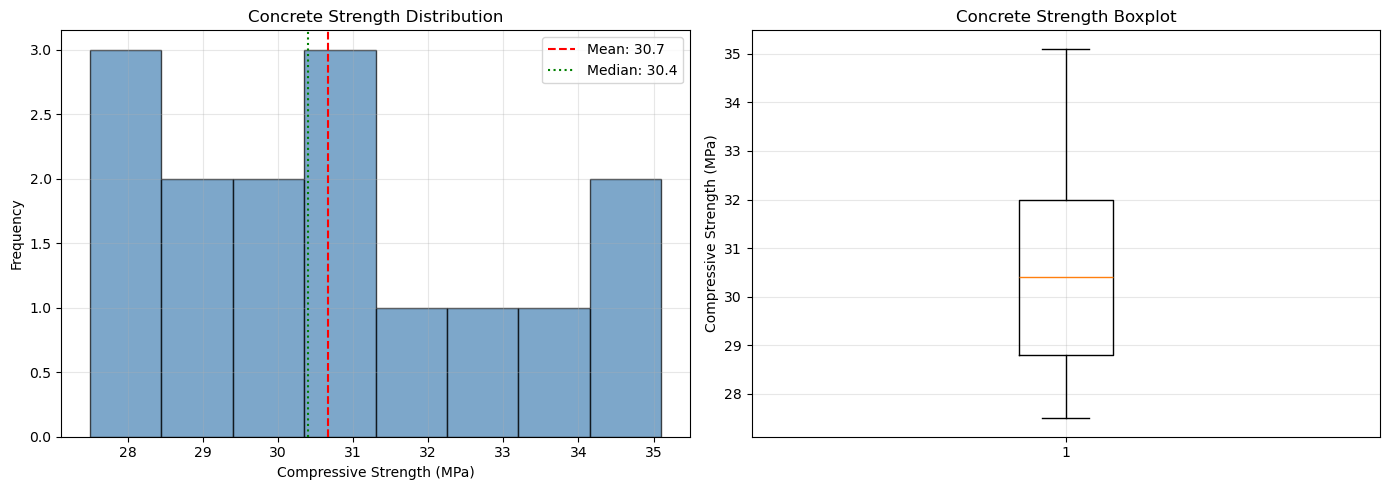

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(strengths, bins=8, alpha=0.7, color='steelblue', edgecolor='black')
ax1.axvline(np.mean(strengths), color='red', linestyle='--', label=f'Mean: {np.mean(strengths):.1f}')
ax1.axvline(np.median(strengths), color='green', linestyle=':', label=f'Median: {np.median(strengths):.1f}')
ax1.set_xlabel('Compressive Strength (MPa)')
ax1.set_ylabel('Frequency')
ax1.set_title('Concrete Strength Distribution')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Boxplot
ax2.boxplot(strengths, vert=True)
ax2.set_ylabel('Compressive Strength (MPa)')
ax2.set_title('Concrete Strength Boxplot')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#
#
#
 
[
T
O
G
E
T
H
E
R
]
 
E
n
g
i
n
e
e
r
i
n
g
 
A
p
p
l
i
c
a
t
i
o
n
:
 
M
a
t
e
r
i
a
l
 
T
e
s
t
i
n
g


*
*
S
c
e
n
a
r
i
o
*
*
:
 
A
 
c
i
v
i
l
 
e
n
g
i
n
e
e
r
 
t
e
s
t
s
 
5
0
 
c
o
n
c
r
e
t
e
 
c
y
l
i
n
d
e
r
s
 
f
r
o
m
 
a
 
b
a
t
c
h
 
t
o
 
d
e
t
e
r
m
i
n
e
 
i
f
 
t
h
e
 
c
o
n
c
r
e
t
e
 
m
e
e
t
s
 
t
h
e
 
d
e
s
i
g
n
 
s
p
e
c
i
f
i
c
a
t
i
o
n
 
o
f
 
$
f
'
_
c
 
=
 
3
0
$
 
M
P
a
.


*
*
P
r
o
c
e
s
s
:
*
*

1
.
 
C
o
l
l
e
c
t
 
5
0
 
c
o
m
p
r
e
s
s
i
v
e
 
s
t
r
e
n
g
t
h
 
m
e
a
s
u
r
e
m
e
n
t
s

2
.
 
C
o
m
p
u
t
e
 
d
e
s
c
r
i
p
t
i
v
e
 
s
t
a
t
i
s
t
i
c
s
 
(
m
e
a
n
,
 
s
t
d
,
 
e
t
c
.
)

3
.
 
V
i
s
u
a
l
i
z
e
 
t
h
e
 
d
i
s
t
r
i
b
u
t
i
o
n

4
.
 
D
e
t
e
r
m
i
n
e
 
i
f
 
t
h
e
 
b
a
t
c
h
 
m
e
e
t
s
 
s
p
e
c
i
f
i
c
a
t
i
o
n


*
*
I
n
t
e
r
p
r
e
t
a
t
i
o
n
:
*
*

-
 
I
f
 
t
h
e
 
m
e
a
n
 
i
s
 
w
e
l
l
 
a
b
o
v
e
 
3
0
 
M
P
a
 
a
n
d
 
t
h
e
 
s
t
a
n
d
a
r
d
 
d
e
v
i
a
t
i
o
n
 
i
s
 
s
m
a
l
l
,
 
t
h
e
 
b
a
t
c
h
 
l
i
k
e
l
y
 
m
e
e
t
s
 
s
p
e
c

-
 
L
a
r
g
e
 
s
t
a
n
d
a
r
d
 
d
e
v
i
a
t
i
o
n
 
i
n
d
i
c
a
t
e
s
 
i
n
c
o
n
s
i
s
t
e
n
t
 
q
u
a
l
i
t
y

-
 
O
u
t
l
i
e
r
s
 
m
a
y
 
i
n
d
i
c
a
t
e
 
t
e
s
t
i
n
g
 
e
r
r
o
r
s
 
o
r
 
c
o
n
t
a
m
i
n
a
t
e
d
 
s
a
m
p
l
e
s

In [11]:
# Simulate 50 concrete cylinder tests
np.random.seed(42)
cylinder_strengths = np.random.normal(loc=33, scale=3.5, size=50)

# Comprehensive descriptive statistics
print("=== Concrete Batch Quality Report ===")
print(f"Number of samples: {len(cylinder_strengths)}")
print(f"Mean strength: {np.mean(cylinder_strengths):.2f} MPa")
print(f"Median strength: {np.median(cylinder_strengths):.2f} MPa")
print(f"Std deviation: {np.std(cylinder_strengths, ddof=1):.2f} MPa")
print(f"Min: {np.min(cylinder_strengths):.2f} MPa")
print(f"Max: {np.max(cylinder_strengths):.2f} MPa")
print(f"Skewness: {stats.skew(cylinder_strengths):.4f}")
print(f"Excess Kurtosis: {stats.kurtosis(cylinder_strengths):.4f}")

# Check specification
spec = 30.0
pct_above_spec = np.mean(cylinder_strengths >= spec) * 100
print(f"\nSamples above {spec} MPa: {pct_above_spec:.1f}%")

=== Concrete Batch Quality Report ===
Number of samples: 50
Mean strength: 32.21 MPa
Median strength: 32.18 MPa
Std deviation: 3.27 MPa
Min: 26.14 MPa
Max: 39.48 MPa
Skewness: 0.1359
Excess Kurtosis: -0.4533

Samples above 30.0 MPa: 74.0%


---
## 2. Probability Review

### Why Probability?

Engineering systems operate under **uncertainty**. Probability provides the mathematical framework to quantify and reason about uncertainty.

**Key Concepts:**
- **Experiment**: A process that produces outcomes (e.g., testing a concrete cylinder)
- **Sample Space ($S$ or $\Omega$)**: The set of all possible outcomes
- **Event ($A$)**: A subset of the sample space
- **Probability ($P(A)$)**: A number between 0 and 1 measuring how likely an event is

### Probability Axioms (Kolmogorov)

For a sample space $S$ and events $A$, $A_1, A_2, \ldots$:

1. **Non-negativity**: $0 \leq P(A) \leq 1$ for any event $A$

2. **Normalization**: $P(S) = 1$

3. **Countable Additivity**: If $A_1, A_2, \ldots$ are mutually disjoint:

$$P\left(\bigcup_{i=1}^{\infty} A_i\right) = \sum_{i=1}^{\infty} P(A_i)$$

**Useful consequences:**
- $P(A^c) = 1 - P(A)$ (complement rule)
- $P(A \cup B) = P(A) + P(B) - P(A \cap B)$ (inclusion-exclusion)
- $P(\emptyset) = 0$

### Sample Spaces and Events

**Examples in Civil Engineering:**

| Experiment | Sample Space $S$ | Example Event $A$ |
|---|---|---|
| Quality control inspection | $\{\text{Pass}, \text{Fail}\}$ | Component passes |
| Roll a die (load category) | $\{1, 2, 3, 4, 5, 6\}$ | Even number |
| Measure concrete strength | $[0, \infty)$ | Strength > 30 MPa |
| Count cracks in a beam | $\{0, 1, 2, \ldots\}$ | Fewer than 3 cracks |

In [12]:
# Simulating sample spaces
import numpy as np

# Example 1: Quality control (Bernoulli trial)
np.random.seed(42)
n_components = 1000
p_pass = 0.95
results = np.random.binomial(1, p_pass, n_components)
print(f"Components passed: {np.sum(results)}/{n_components}")
print(f"Empirical P(pass): {np.mean(results):.4f}")

# Example 2: Die roll
n_rolls = 10000
rolls = np.random.randint(1, 7, n_rolls)
print(f"\nDie roll simulation ({n_rolls} rolls):")
for i in range(1, 7):
    print(f"  P({i}) = {np.mean(rolls == i):.4f} (theoretical: {1/6:.4f})")

Components passed: 954/1000
Empirical P(pass): 0.9540

Die roll simulation (10000 rolls):
  P(1) = 0.1699 (theoretical: 0.1667)
  P(2) = 0.1708 (theoretical: 0.1667)
  P(3) = 0.1613 (theoretical: 0.1667)
  P(4) = 0.1653 (theoretical: 0.1667)
  P(5) = 0.1682 (theoretical: 0.1667)
  P(6) = 0.1645 (theoretical: 0.1667)


### Conditional Probability

The probability of event $A$ occurring **given that** event $B$ has occurred:

$$P(A|B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0$$

This is fundamental in engineering because we often have **partial information** about a system.

**Multiplication Rule:**
$$P(A \cap B) = P(A|B) \cdot P(B) = P(B|A) \cdot P(A)$$

In [13]:
# Quality control example
p_defective = 0.05
p_detected_given_defective = 0.90
p_detected_given_good = 0.02

# P(Detected AND Defective)
p_detected_and_defective = p_detected_given_defective * p_defective
print(f"P(Detected and Defective) = {p_detected_and_defective:.4f}")

# Total probability of detection
p_good = 1 - p_defective
p_detected = p_detected_given_defective * p_defective + p_detected_given_good * p_good
print(f"P(Detected) = {p_detected:.4f}")

P(Detected and Defective) = 0.0450
P(Detected) = 0.0640


### Independence

Two events $A$ and $B$ are **independent** if and only if:

$$P(A \cap B) = P(A) \cdot P(B)$$

Equivalently: $P(A|B) = P(A)$, meaning knowing $B$ occurred gives no information about $A$.

> **Important: Common Mistake**
> Disjoint (mutually exclusive) events are **NOT** independent! In fact, if $P(A) > 0$ and $P(B) > 0$, then disjoint events are **dependent** because $P(A \cap B) = 0 \neq P(A) \cdot P(B)$.

**Engineering Example:** The failure of two independent bridge components:
- $P(A) = 0.01$ (Component A fails)
- $P(B) = 0.02$ (Component B fails)
- $P(\text{both fail}) = P(A) \cdot P(B) = 0.0002$ (if independent)

### Law of Total Probability and Bayes' Theorem

**Law of Total Probability:**

If $B_1, B_2, \ldots, B_n$ form a **partition** of $S$ (mutually exclusive and exhaustive):

$$P(A) = \sum_{i=1}^{n} P(A|B_i)P(B_i)$$

**Bayes' Theorem:**

$$P(B_i|A) = \frac{P(A|B_i)P(B_i)}{P(A)} = \frac{P(A|B_i)P(B_i)}{\sum_{j=1}^{n} P(A|B_j)P(B_j)}$$

Bayes' Theorem allows us to **update our beliefs** about hypotheses given new evidence.

In [14]:
# Bayes' Theorem: Structural damage testing
sensitivity = 0.95  # P(+|Damage)
specificity = 0.90  # P(-|No Damage)  
prevalence = 0.05   # P(Damage)

# P(Damage|+) using Bayes' Theorem
p_positive_given_damage = sensitivity
p_positive_given_no_damage = 1 - specificity
p_damage = prevalence
p_no_damage = 1 - prevalence

p_positive = p_positive_given_damage * p_damage + p_positive_given_no_damage * p_no_damage
p_damage_given_positive = (p_positive_given_damage * p_damage) / p_positive

print(f"P(Damage | Positive test) = {p_damage_given_positive:.4f}")
print(f"Only {p_damage_given_positive*100:.1f}% probability despite positive test!")
print("This is due to the low prevalence (base rate) effect.")

P(Damage | Positive test) = 0.3333
Only 33.3% probability despite positive test!
This is due to the low prevalence (base rate) effect.


> **Key Insight: Base Rate Fallacy**
> Even with a highly accurate test (95% sensitivity, 90% specificity), a positive result may still have a low probability of being truly positive when the prevalence (base rate) is low. This is critical in structural health monitoring, medical screening, and quality control.

#
#
#
 
[
L
I
V
E
]
 
V
i
s
u
a
l
i
z
i
n
g
 
B
a
y
e
s
'
 
T
h
e
o
r
e
m

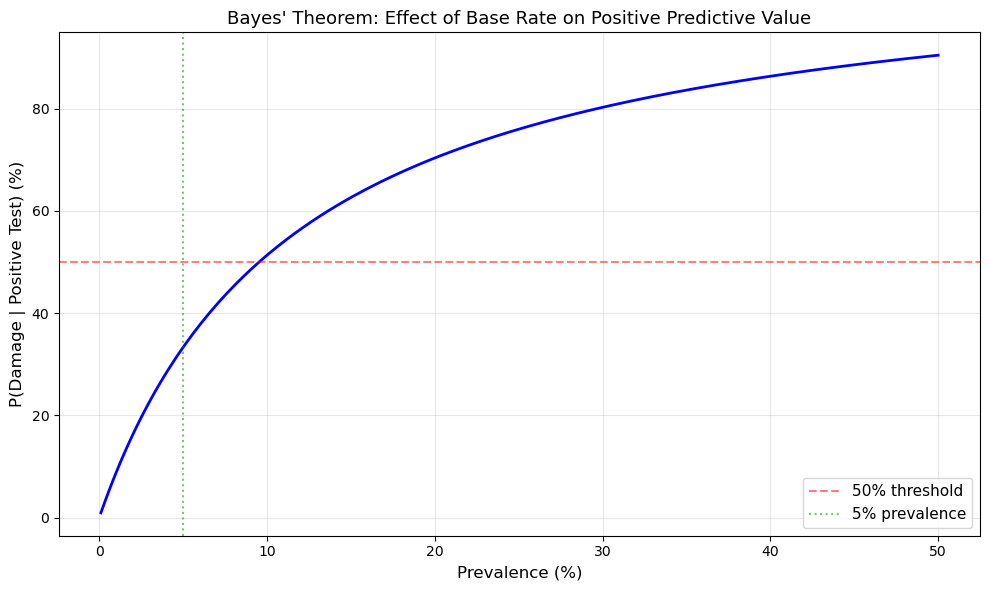

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Show how P(Damage|+) changes with prevalence
prevalences = np.linspace(0.001, 0.5, 200)
ppv_values = []

for prev in prevalences:
    p_pos = sensitivity * prev + (1 - specificity) * (1 - prev)
    ppv = (sensitivity * prev) / p_pos
    ppv_values.append(ppv)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(prevalences * 100, np.array(ppv_values) * 100, 'b-', linewidth=2)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.axvline(x=5, color='green', linestyle=':', alpha=0.5, label='5% prevalence')
ax.set_xlabel('Prevalence (%)', fontsize=12)
ax.set_ylabel('P(Damage | Positive Test) (%)', fontsize=12)
ax.set_title("Bayes' Theorem: Effect of Base Rate on Positive Predictive Value", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Discrete Random Variables and Distributions

### Random Variables

A **random variable** $X$ is a function that maps outcomes from a sample space $S$ to real numbers:

$$X: S \to \mathbb{R}$$

**Two types:**
- **Discrete**: Takes countably many values (e.g., number of cracks, number of defective components)
- **Continuous**: Takes any value in an interval (e.g., concrete strength, beam deflection)

### Probability Mass Function (PMF)

For a discrete random variable $X$, the **PMF** gives the probability of each possible value:

$$p_X(x) = P(X = x)$$

**Properties:**
- $p_X(x) \geq 0$ for all $x$
- $\sum_x p_X(x) = 1$

### Cumulative Distribution Function (CDF)

$$F_X(x) = P(X \leq x) = \sum_{t \leq x} p_X(t)$$

**Properties:**
- $0 \leq F_X(x) \leq 1$
- $F_X$ is non-decreasing
- $\lim_{x \to -\infty} F_X(x) = 0$, $\lim_{x \to \infty} F_X(x) = 1$

### Bernoulli Distribution

The simplest discrete distribution: a single trial with two outcomes (success/failure).

$$X \sim \text{Bernoulli}(p)$$

**PMF:**
$$p_X(x) = \begin{cases} p & \text{if } x = 1 \text{ (success)} \\ 1-p & \text{if } x = 0 \text{ (failure)} \end{cases}$$

**Properties:**
- $E[X] = p$
- $Var(X) = p(1-p)$

**Engineering Example:** A single component either passes ($X=1$) or fails ($X=0$) quality control.

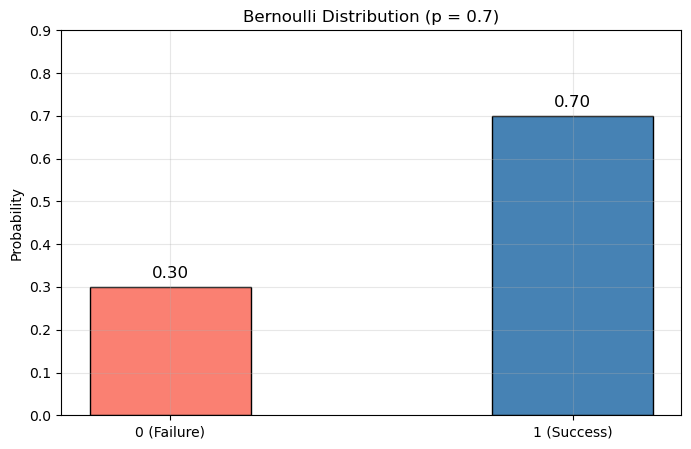

E[X] = 0.7
Var(X) = 0.21


In [16]:
from scipy import stats
import matplotlib.pyplot as plt

# Bernoulli Distribution
p = 0.7
x = [0, 1]
pmf = [1 - p, p]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x, pmf, color=['salmon', 'steelblue'], width=0.4, edgecolor='black')
ax.set_xticks([0, 1])
ax.set_xticklabels(['0 (Failure)', '1 (Success)'])
ax.set_ylabel('Probability')
ax.set_title(f'Bernoulli Distribution (p = {p})')
ax.set_ylim(0, 0.9)
for i, v in zip(x, pmf):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=12)
ax.grid(True, alpha=0.3)
plt.show()

print(f"E[X] = {p}")
print(f"Var(X) = {p*(1-p):.2f}")

### Binomial Distribution

The number of successes in $n$ independent Bernoulli trials.

$$X \sim \text{Bin}(n, p)$$

**PMF:**
$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0, 1, \ldots, n$$

**Properties:**
- $E[X] = np$
- $Var(X) = np(1-p)$

**Engineering Example:** Out of 20 welds inspected, how many are defective? (Each weld has a 30% chance of being defective.)

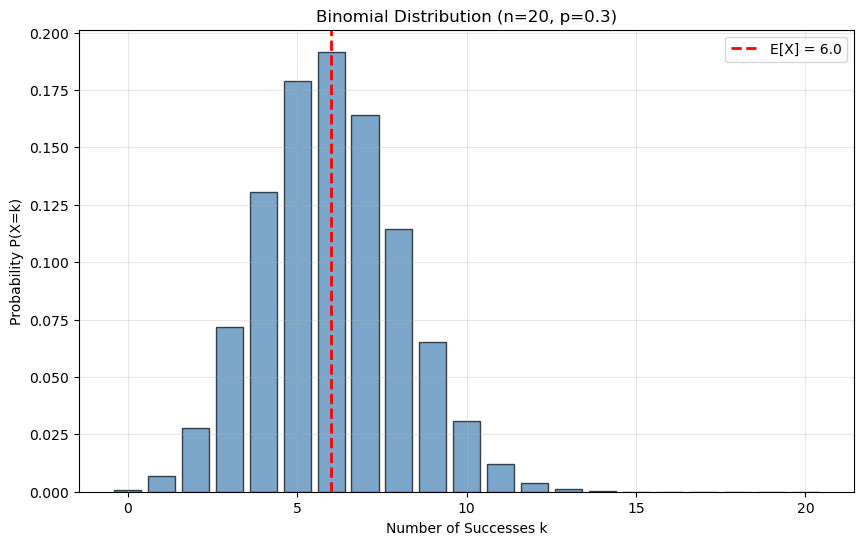

In [17]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Binomial Distribution
n, p = 20, 0.3
x = np.arange(0, n + 1)
pmf = stats.binom.pmf(x, n, p)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x, pmf, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(n * p, color='red', linestyle='--', linewidth=2, label=f'E[X] = {n*p}')
ax.set_xlabel('Number of Successes k')
ax.set_ylabel('Probability P(X=k)')
ax.set_title(f'Binomial Distribution (n={n}, p={p})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [18]:
# Binomial probabilities - engineering example
n, p = 20, 0.3

# P(X = 5)
print(f"P(X = 5) = {stats.binom.pmf(5, n, p):.4f}")

# P(X <= 3)
print(f"P(X <= 3) = {stats.binom.cdf(3, n, p):.4f}")

# P(X > 8)
print(f"P(X > 8) = {1 - stats.binom.cdf(8, n, p):.4f}")

print(f"\nE[X] = np = {n*p}")
print(f"Var(X) = np(1-p) = {n*p*(1-p)}")
print(f"SD(X) = {np.sqrt(n*p*(1-p)):.4f}")

P(X = 5) = 0.1789
P(X <= 3) = 0.1071
P(X > 8) = 0.1133

E[X] = np = 6.0
Var(X) = np(1-p) = 4.199999999999999
SD(X) = 2.0494


### Poisson Distribution

Models the number of events occurring in a fixed interval of time or space, when events occur independently at a constant average rate.

$$X \sim \text{Poisson}(\lambda)$$

**PMF:**
$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k = 0, 1, 2, \ldots$$

**Properties:**
- $E[X] = \lambda$
- $Var(X) = \lambda$
- Mean equals variance (a distinctive property!)

**Civil Engineering Examples:**
- Number of trucks crossing a bridge per hour
- Number of accidents at an intersection per year
- Number of defects per 100m of pipeline

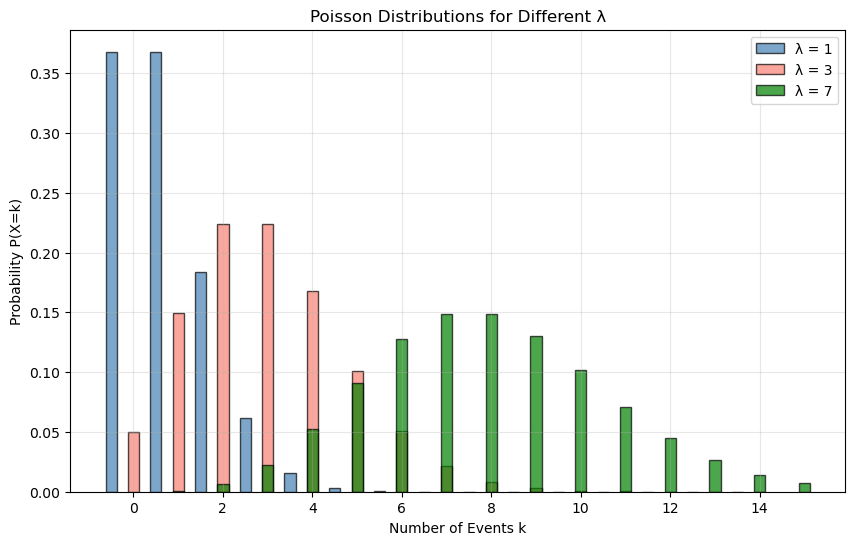

In [19]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Poisson Distribution - comparing different lambda values
fig, ax = plt.subplots(figsize=(10, 6))

for lam, color in zip([1, 3, 7], ['steelblue', 'salmon', 'green']):
    x = np.arange(0, 15)
    pmf = stats.poisson.pmf(x, lam)
    ax.bar(x + (lam-3)*0.25, pmf, width=0.25, alpha=0.7,
           color=color, label=f'\u03bb = {lam}', edgecolor='black')

ax.set_xlabel('Number of Events k')
ax.set_ylabel('Probability P(X=k)')
ax.set_title('Poisson Distributions for Different \u03bb')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [20]:
# Poisson example: Trucks crossing a bridge
lam = 5  # Average 5 trucks per hour

print(f"Average trucks per hour: {lam}")
print(f"P(X = 3) = {stats.poisson.pmf(3, lam):.4f}")
print(f"P(X <= 3) = {stats.poisson.cdf(3, lam):.4f}")
print(f"P(X > 8) = {1 - stats.poisson.cdf(8, lam):.4f}")
print(f"E[X] = {lam}")
print(f"Var(X) = {lam}")

Average trucks per hour: 5
P(X = 3) = 0.1404
P(X <= 3) = 0.2650
P(X > 8) = 0.0681
E[X] = 5
Var(X) = 5


### Geometric Distribution

Models the number of trials until the **first success** in a sequence of independent Bernoulli trials.

$$X \sim \text{Geo}(p)$$

**PMF:**
$$P(X = k) = (1-p)^{k-1} p, \quad k = 1, 2, 3, \ldots$$

**Properties:**
- $E[X] = \frac{1}{p}$
- $Var(X) = \frac{1-p}{p^2}$
- **Memoryless property**: $P(X > m + n \mid X > m) = P(X > n)$

**Engineering Example:** How many welds must be inspected until the first defective one is found?

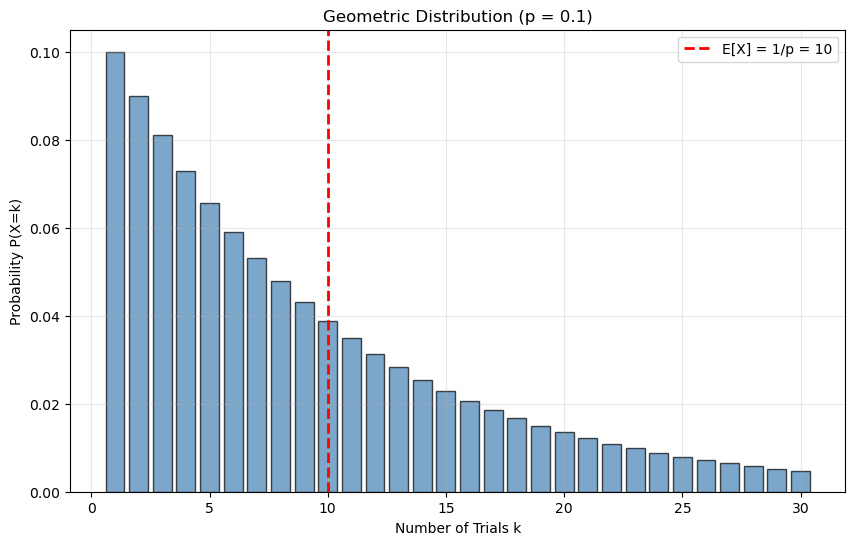

E[X] = 1/p = 10.0 inspections
Var(X) = (1-p)/p² = 90.00


In [21]:
# Geometric distribution visualization
p_defect = 0.1  # 10% defect rate
k = np.arange(1, 31)
pmf = stats.geom.pmf(k, p_defect)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(k, pmf, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(1/p_defect, color='red', linestyle='--', linewidth=2, 
           label=f'E[X] = 1/p = {1/p_defect:.0f}')
ax.set_xlabel('Number of Trials k')
ax.set_ylabel('Probability P(X=k)')
ax.set_title(f'Geometric Distribution (p = {p_defect})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"E[X] = 1/p = {1/p_defect:.1f} inspections")
print(f"Var(X) = (1-p)/p\u00b2 = {(1-p_defect)/p_defect**2:.2f}")

---
## 4. Expectation and Variance Concepts

### Expected Value (Mean)

The **expected value** is the long-run average of a random variable.

**Discrete case:**
$$E[X] = \sum_x x \cdot p_X(x)$$

**Continuous case:**
$$E[X] = \int_{-\infty}^{\infty} x \, f_X(x) \, dx$$

### Linearity of Expectation

One of the most powerful properties in probability:

$$E[aX + bY] = aE[X] + bE[Y]$$

This holds **always**, even when $X$ and $Y$ are dependent!

> **Important: Non-Linearity Warning**
> In general, $E[g(X)] \neq g(E[X])$. For example:
> $$E[X^2] \neq (E[X])^2$$
> This inequality is at the heart of the variance formula.

### LOTUS (Law of the Unconscious Statistician)

To compute $E[g(X)]$ without finding the distribution of $g(X)$:

**Discrete:**
$$E[g(X)] = \sum_x g(x) \, p_X(x)$$

**Continuous:**
$$E[g(X)] = \int_{-\infty}^{\infty} g(x) \, f_X(x) \, dx$$

This is extremely useful because it avoids the need to derive the distribution of $g(X)$.

### Variance

Variance measures the expected squared deviation from the mean:

$$Var(X) = E[(X - E[X])^2] = E[X^2] - (E[X])^2$$

**Properties:**
- $Var(X) \geq 0$
- $Var(aX + b) = a^2 Var(X)$ (scaling and shifting)
- $Var(X) = 0 \iff X$ is constant
- For **independent** $X$ and $Y$: $Var(X + Y) = Var(X) + Var(Y)$

**Standard Deviation:**
$$SD(X) = \sqrt{Var(X)}$$

In [22]:
import numpy as np

# Die roll example
outcomes = np.arange(1, 7)
probs = np.ones(6) / 6

# E[X]
ex = np.sum(outcomes * probs)
# E[X^2]
ex2 = np.sum(outcomes**2 * probs)
# Var(X)
var_x = ex2 - ex**2

print(f"E[X] = {ex:.4f}")
print(f"E[X\u00b2] = {ex2:.4f}")
print(f"Var(X) = E[X\u00b2] - (E[X])\u00b2 = {ex2:.4f} - {ex**2:.4f} = {var_x:.4f}")
print(f"SD(X) = {np.sqrt(var_x):.4f}")

E[X] = 3.5000
E[X²] = 15.1667
Var(X) = E[X²] - (E[X])² = 15.1667 - 12.2500 = 2.9167
SD(X) = 1.7078


### Variance of Common Distributions

| Distribution | $E[X]$ | $Var(X)$ |
|---|---|---|
| Bernoulli($p$) | $p$ | $p(1-p)$ |
| Binomial($n, p$) | $np$ | $np(1-p)$ |
| Poisson($\lambda$) | $\lambda$ | $\lambda$ |
| Geometric($p$) | $1/p$ | $(1-p)/p^2$ |

In [23]:
# [TOGETHER] Verify variance formulas via simulation
np.random.seed(42)
n_sim = 100000

# Binomial(20, 0.3)
n, p = 20, 0.3
binom_samples = np.random.binomial(n, p, n_sim)
print(f"Binomial(n={n}, p={p}):")
print(f"  Theoretical: E[X]={n*p:.2f}, Var(X)={n*p*(1-p):.2f}")
print(f"  Simulated:   E[X]={np.mean(binom_samples):.2f}, Var(X)={np.var(binom_samples, ddof=1):.2f}")

# Poisson(5)
lam = 5
pois_samples = np.random.poisson(lam, n_sim)
print(f"\nPoisson(λ={lam}):")
print(f"  Theoretical: E[X]={lam}, Var(X)={lam}")
print(f"  Simulated:   E[X]={np.mean(pois_samples):.2f}, Var(X)={np.var(pois_samples, ddof=1):.2f}")

# Geometric(0.2)
p_geo = 0.2
geo_samples = np.random.geometric(p_geo, n_sim)
print(f"\nGeometric(p={p_geo}):")
print(f"  Theoretical: E[X]={1/p_geo:.2f}, Var(X)={(1-p_geo)/p_geo**2:.2f}")
print(f"  Simulated:   E[X]={np.mean(geo_samples):.2f}, Var(X)={np.var(geo_samples, ddof=1):.2f}")


Binomial(n=20, p=0.3):
  Theoretical: E[X]=6.00, Var(X)=4.20
  Simulated:   E[X]=6.00, Var(X)=4.18

Poisson(λ=5):
  Theoretical: E[X]=5, Var(X)=5
  Simulated:   E[X]=5.01, Var(X)=5.01

Geometric(p=0.2):
  Theoretical: E[X]=5.00, Var(X)=20.00
  Simulated:   E[X]=4.99, Var(X)=19.94


---
## 5. Continuous Random Variables and Distributions

### Continuous Random Variables

A continuous random variable takes values in an interval (or union of intervals).

**Probability Density Function (PDF):**

$$f_X(x) \geq 0 \quad \text{and} \quad \int_{-\infty}^{\infty} f_X(x) \, dx = 1$$

The probability that $X$ falls in an interval $[a, b]$:

$$P(a \leq X \leq b) = \int_a^b f_X(x) \, dx$$

**Important:** For continuous RVs, $P(X = x) = 0$ for any specific value $x$.

**Cumulative Distribution Function (CDF):**

$$F_X(x) = P(X \leq x) = \int_{-\infty}^{x} f_X(t) \, dt$$

**Relationship:** $f_X(x) = F_X'(x)$ (the PDF is the derivative of the CDF)

### Uniform Distribution

$$X \sim \text{Uniform}(a, b)$$

**PDF:**
$$f_X(x) = \begin{cases} \frac{1}{b-a} & \text{if } a \leq x \leq b \\ 0 & \text{otherwise} \end{cases}$$

**Properties:**
- $E[X] = \frac{a+b}{2}$
- $Var(X) = \frac{(b-a)^2}{12}$

**Engineering Example:** Time of arrival of a vehicle at a traffic signal (within one cycle).

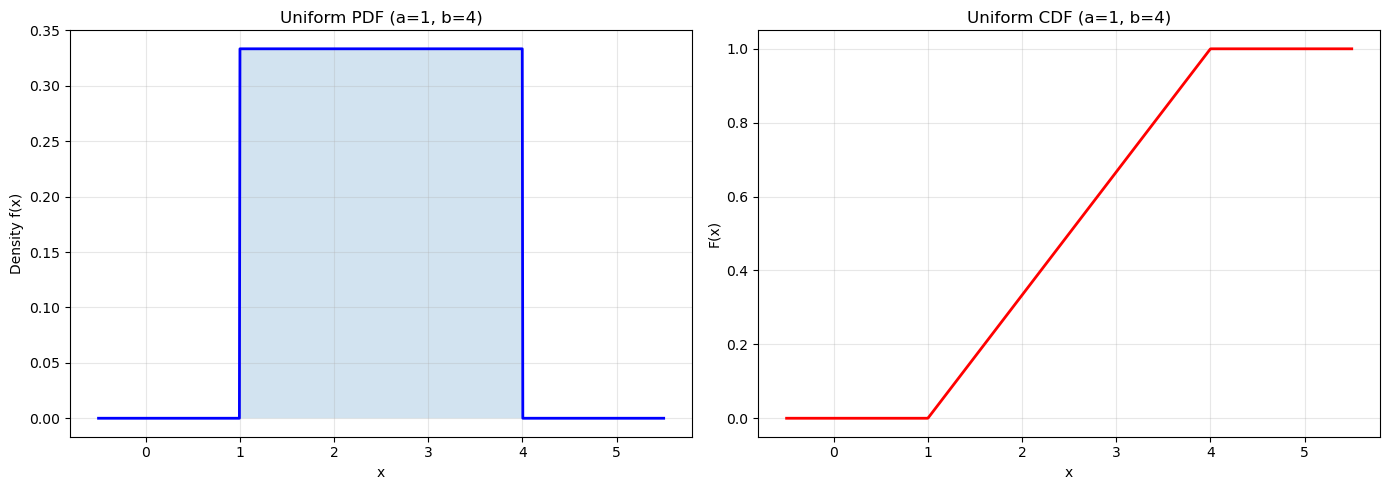

E[X] = 2.5
Var(X) = 0.7500


In [24]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Uniform Distribution
a, b = 1, 4
x = np.linspace(-0.5, 5.5, 1000)
pdf = stats.uniform.pdf(x, loc=a, scale=b-a)
cdf = stats.uniform.cdf(x, loc=a, scale=b-a)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(x, pdf, 'b-', linewidth=2)
ax1.fill_between(x, pdf, alpha=0.2)
ax1.set_xlabel('x')
ax1.set_ylabel('Density f(x)')
ax1.set_title(f'Uniform PDF (a={a}, b={b})')
ax1.grid(True, alpha=0.3)

ax2.plot(x, cdf, 'r-', linewidth=2)
ax2.set_xlabel('x')
ax2.set_ylabel('F(x)')
ax2.set_title(f'Uniform CDF (a={a}, b={b})')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"E[X] = {(a+b)/2}")
print(f"Var(X) = {(b-a)**2/12:.4f}")

### Normal (Gaussian) Distribution

The **most important** distribution in statistics and engineering.

$$X \sim N(\mu, \sigma^2)$$

**PDF:**
$$f_X(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

**Properties:**
- $E[X] = \mu$
- $Var(X) = \sigma^2$
- Symmetric about $\mu$
- Bell-shaped curve
- Completely determined by $\mu$ and $\sigma$

**Why is it so important?**
1. Many natural phenomena follow a normal distribution (Central Limit Theorem)
2. Measurement errors are often normally distributed
3. Sum of many independent random variables tends toward normal
4. Material properties (strength, modulus) often approximately normal

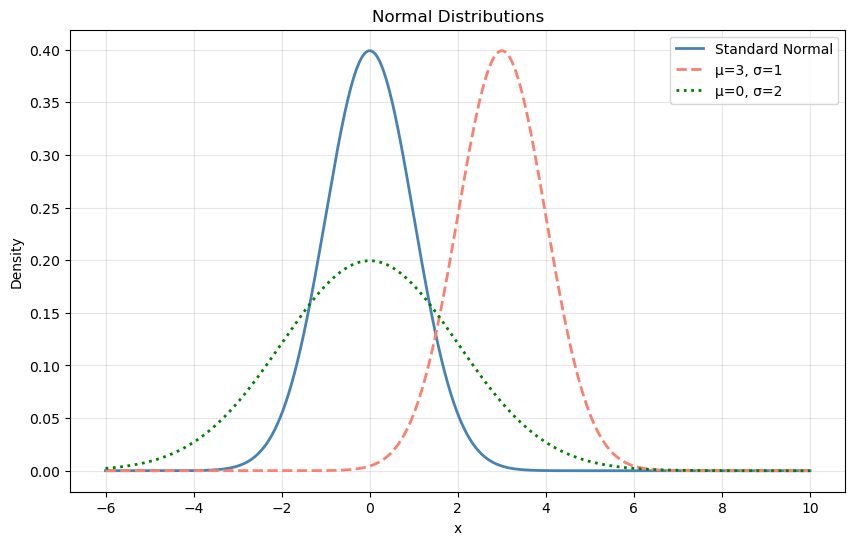

In [25]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Normal distributions with different parameters
x = np.linspace(-6, 10, 1000)

fig, ax = plt.subplots(figsize=(10, 6))

params = [(0, 1, 'Standard Normal'), (3, 1, '\u03bc=3, \u03c3=1'), (0, 2, '\u03bc=0, \u03c3=2')]
colors = ['steelblue', 'salmon', 'green']
styles = ['-', '--', ':']

for (mu, sigma, label), color, style in zip(params, colors, styles):
    pdf = stats.norm.pdf(x, mu, sigma)
    ax.plot(x, pdf, color=color, linestyle=style, linewidth=2, label=label)

ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_title('Normal Distributions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### The 68-95-99.7 Rule (Empirical Rule)

For a normal distribution $N(\mu, \sigma^2)$:

- **68%** of data falls within $\mu \pm 1\sigma$
- **95%** of data falls within $\mu \pm 2\sigma$
- **99.7%** of data falls within $\mu \pm 3\sigma$

This rule is crucial for quality control, specification limits, and anomaly detection.

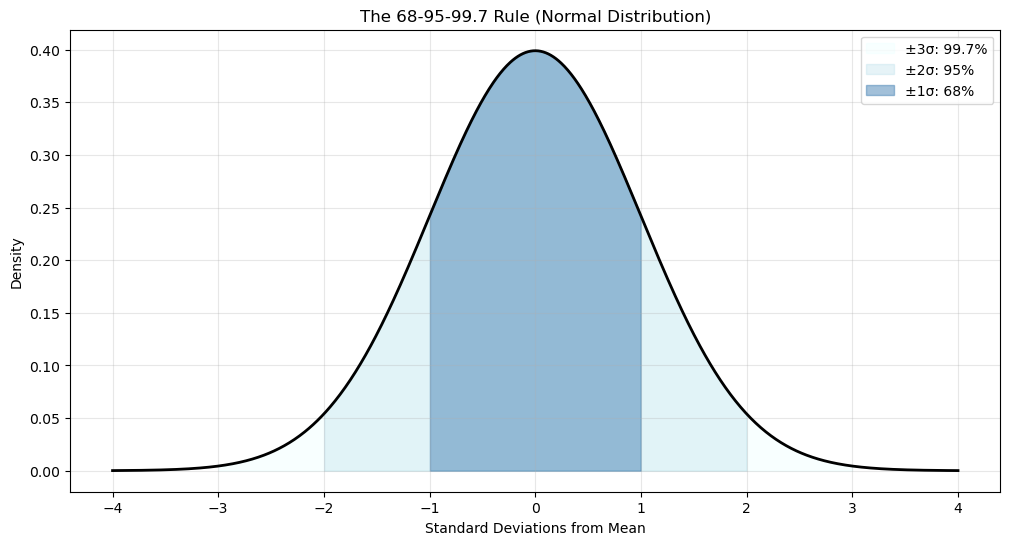

Steel yield strength: μ=250 MPa, σ=15 MPa
68% between 235 and 265 MPa
95% between 220 and 280 MPa
99.7% between 205 and 295 MPa


In [26]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# 68-95-99.7 Rule visualization
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, y, 'k-', linewidth=2)

# Fill regions
colors = ['steelblue', 'lightblue', 'lightcyan']
alphas = [0.5, 0.3, 0.2]
labels = ['68%', '95%', '99.7%']
sigmas = [1, 2, 3]

for sigma, color, alpha, label in zip(reversed(sigmas), reversed(colors), 
                                       reversed(alphas), reversed(labels)):
    ax.fill_between(x, y, where=(x >= -sigma) & (x <= sigma),
                    color=color, alpha=alpha, label=f'\u00b1{sigma}\u03c3: {label}')

ax.set_xlabel('Standard Deviations from Mean')
ax.set_ylabel('Density')
ax.set_title('The 68-95-99.7 Rule (Normal Distribution)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Engineering example
mu, sigma = 250, 15  # Steel yield strength
print(f"Steel yield strength: \u03bc={mu} MPa, \u03c3={sigma} MPa")
print(f"68% between {mu-sigma} and {mu+sigma} MPa")
print(f"95% between {mu-2*sigma} and {mu+2*sigma} MPa")
print(f"99.7% between {mu-3*sigma} and {mu+3*sigma} MPa")

### Standard Normal Distribution and Z-scores

The **standard normal** distribution has $\mu = 0$ and $\sigma = 1$:

$$Z \sim N(0, 1)$$

Any normal random variable can be **standardized**:

$$Z = \frac{X - \mu}{\sigma}$$

This allows us to use standard normal tables or `scipy.stats.norm` to compute any normal probability.

In [27]:
# Standard normal calculations
mu, sigma = 250, 15  # Steel yield strength

# P(X < 230)
z = (230 - mu) / sigma
print(f"P(X < 230) = P(Z < {z:.2f}) = {stats.norm.cdf(z):.4f}")

# P(240 < X < 260)
z1 = (240 - mu) / sigma
z2 = (260 - mu) / sigma
prob = stats.norm.cdf(z2) - stats.norm.cdf(z1)
print(f"P(240 < X < 260) = {prob:.4f}")

# Find the value such that 5% of steels are below it
x_5pct = stats.norm.ppf(0.05, mu, sigma)
print(f"5th percentile: {x_5pct:.2f} MPa")

P(X < 230) = P(Z < -1.33) = 0.0912
P(240 < X < 260) = 0.4950
5th percentile: 225.33 MPa


### Exponential Distribution

Models the time between events in a Poisson process.

$$X \sim \text{Expo}(\lambda)$$

**PDF:**
$$f_X(x) = \lambda e^{-\lambda x}, \quad x \geq 0$$

**Properties:**
- $E[X] = \frac{1}{\lambda}$
- $Var(X) = \frac{1}{\lambda^2}$
- **Memoryless property**: $P(X > s + t \mid X > s) = P(X > t)$

**Engineering Example:** Time between arrivals of vehicles, time to failure of a component.

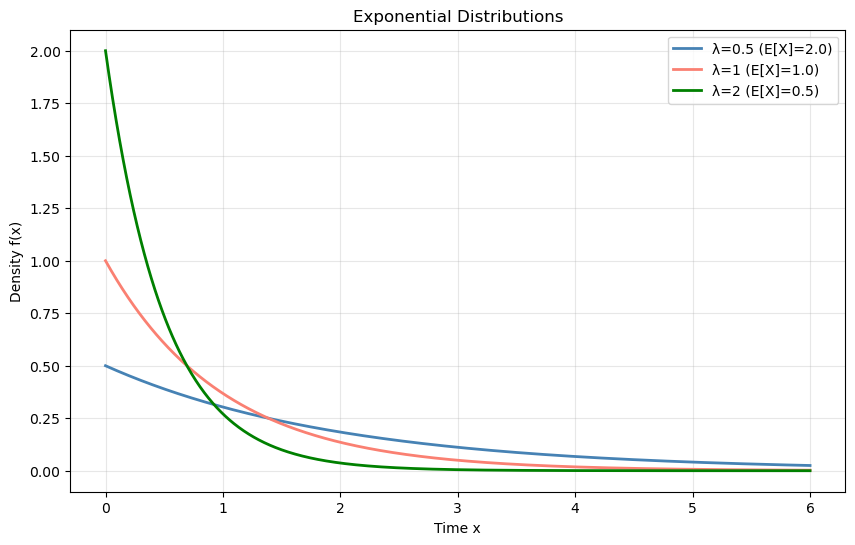

In [28]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Exponential Distribution
x = np.linspace(0, 6, 1000)

fig, ax = plt.subplots(figsize=(10, 6))

for lam, color in zip([0.5, 1, 2], ['steelblue', 'salmon', 'green']):
    pdf = stats.expon.pdf(x, scale=1/lam)
    ax.plot(x, pdf, color=color, linewidth=2,
            label=f'\u03bb={lam} (E[X]={1/lam:.1f})')

ax.set_xlabel('Time x')
ax.set_ylabel('Density f(x)')
ax.set_title('Exponential Distributions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [29]:
# Exponential example: Time between equipment failures
lam = 0.5  # Average 0.5 failures per year (i.e., 1 failure every 2 years)

print(f"Rate parameter \u03bb = {lam} failures/year")
print(f"Mean time to failure E[X] = 1/\u03bb = {1/lam:.1f} years")
print(f"\nP(fail within 1 year) = {stats.expon.cdf(1, scale=1/lam):.4f}")
print(f"P(fail within 3 years) = {stats.expon.cdf(3, scale=1/lam):.4f}")
print(f"P(survive more than 5 years) = {1 - stats.expon.cdf(5, scale=1/lam):.4f}")

Rate parameter λ = 0.5 failures/year
Mean time to failure E[X] = 1/λ = 2.0 years

P(fail within 1 year) = 0.3935
P(fail within 3 years) = 0.7769
P(survive more than 5 years) = 0.0821


> **Key Insight: Connecting Poisson and Exponential**
> If events occur at a constant rate $\lambda$ per unit time (Poisson process):
> - The **number** of events in a fixed interval follows $\text{Poisson}(\lambda t)$
> - The **time** between consecutive events follows $\text{Expo}(\lambda)$
>
> Example: If trucks arrive at a rate of 5 per hour (Poisson), the time between arrivals is $\text{Expo}(5)$ with mean 12 minutes.

#
#
#
 
[
P
R
A
C
T
I
C
E
]
 
C
o
m
p
a
r
i
n
g
 
C
o
n
t
i
n
u
o
u
s
 
D
i
s
t
r
i
b
u
t
i
o
n
s

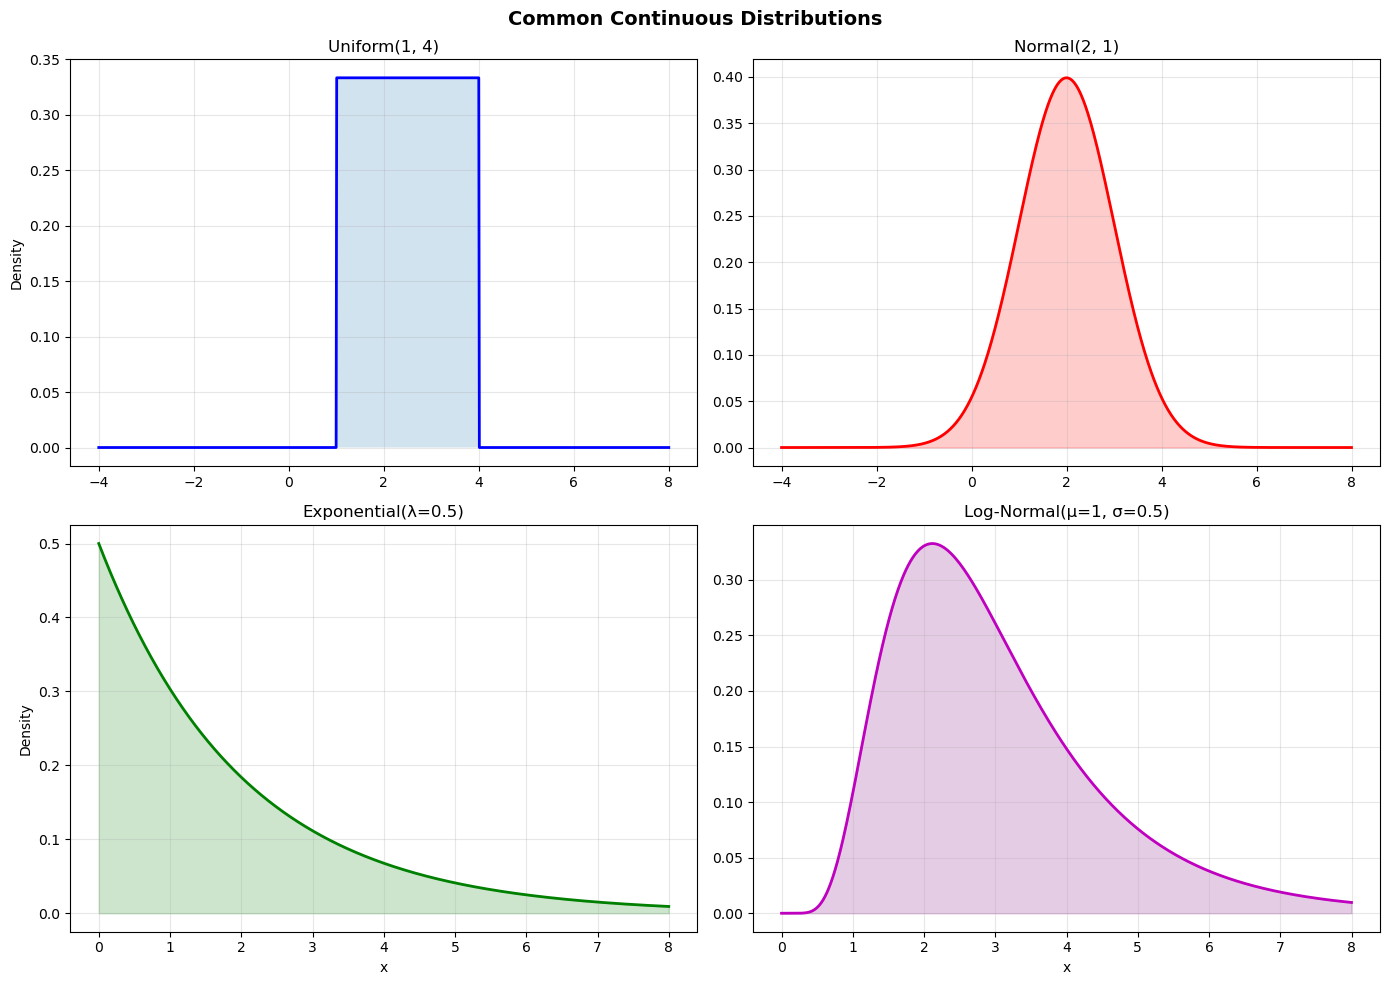

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x_range = np.linspace(-4, 8, 1000)

# Uniform
axes[0, 0].plot(x_range, stats.uniform.pdf(x_range, loc=1, scale=3), 'b-', linewidth=2)
axes[0, 0].fill_between(x_range, stats.uniform.pdf(x_range, loc=1, scale=3), alpha=0.2)
axes[0, 0].set_title('Uniform(1, 4)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].grid(True, alpha=0.3)

# Normal
axes[0, 1].plot(x_range, stats.norm.pdf(x_range, 2, 1), 'r-', linewidth=2)
axes[0, 1].fill_between(x_range, stats.norm.pdf(x_range, 2, 1), alpha=0.2, color='red')
axes[0, 1].set_title('Normal(2, 1)')
axes[0, 1].grid(True, alpha=0.3)

# Exponential
x_pos = np.linspace(0, 8, 1000)
axes[1, 0].plot(x_pos, stats.expon.pdf(x_pos, scale=2), 'g-', linewidth=2)
axes[1, 0].fill_between(x_pos, stats.expon.pdf(x_pos, scale=2), alpha=0.2, color='green')
axes[1, 0].set_title('Exponential(\u03bb=0.5)')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('Density')
axes[1, 0].grid(True, alpha=0.3)

# Log-normal
axes[1, 1].plot(x_pos, stats.lognorm.pdf(x_pos, s=0.5, scale=np.exp(1)), 'm-', linewidth=2)
axes[1, 1].fill_between(x_pos, stats.lognorm.pdf(x_pos, s=0.5, scale=np.exp(1)), alpha=0.2, color='purple')
axes[1, 1].set_title('Log-Normal(\u03bc=1, \u03c3=0.5)')
axes[1, 1].set_xlabel('x')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Common Continuous Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Moments and Summary Measures

### Definition of Moments

**Moments** provide a systematic way to characterize the shape of a distribution.

**Raw Moments** (about the origin):
$$\mu_n' = E[X^n]$$

**Central Moments** (about the mean):
$$\mu_n = E[(X - \mu)^n]$$

where $\mu = E[X]$.

### Mean and Variance as Moments

| Moment | Formula | Measures |
|---|---|---|
| 1st raw moment | $\mu_1' = E[X]$ | Center (Mean) |
| 2nd central moment | $\mu_2 = E[(X-\mu)^2]$ | Spread (Variance) |
| 3rd standardized moment | $\gamma_1 = \mu_3 / \sigma^3$ | Asymmetry (Skewness) |
| 4th standardized moment | $\gamma_2 = \mu_4 / \sigma^4 - 3$ | Tail heaviness (Excess Kurtosis) |

### Skewness (3rd Standardized Moment)

$$\gamma_1 = \frac{E[(X - \mu)^3]}{\sigma^3}$$

- $\gamma_1 = 0$: Symmetric distribution
- $\gamma_1 > 0$: Right-skewed (long right tail)
- $\gamma_1 < 0$: Left-skewed (long left tail)

### Kurtosis (4th Standardized Moment)

$$\gamma_2 = \frac{E[(X - \mu)^4]}{\sigma^4} - 3$$

The "$-3$" gives us **excess kurtosis** (relative to normal distribution):
- $\gamma_2 = 0$: Normal-like tails (mesokurtic)
- $\gamma_2 > 0$: Heavier tails than normal (leptokurtic)
- $\gamma_2 < 0$: Lighter tails than normal (platykurtic)

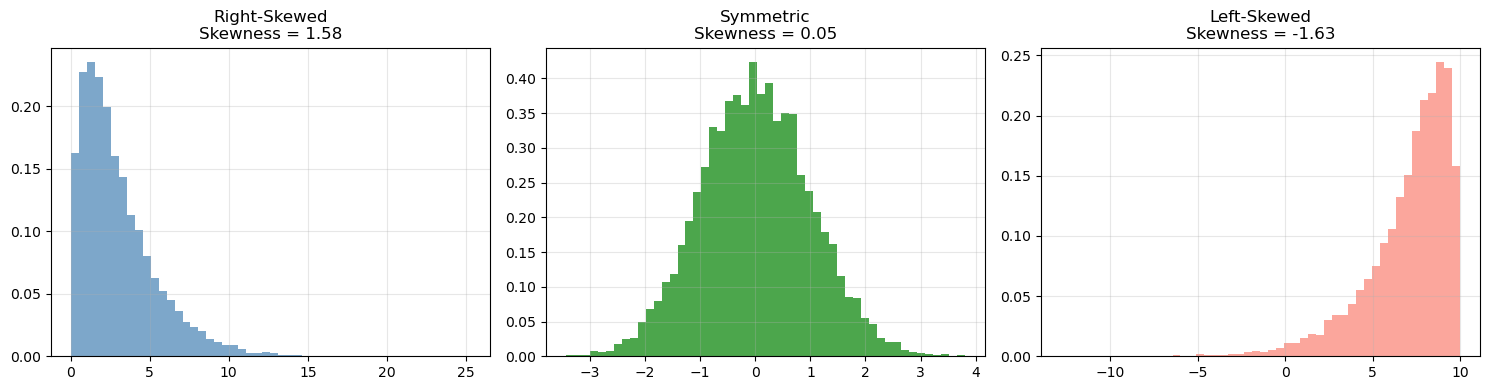

In [31]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Demonstrate different skewness
np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Right-skewed (positive skewness)
data_right = stats.chi2.rvs(df=3, size=10000)
axes[0].hist(data_right, bins=50, density=True, alpha=0.7, color='steelblue')
axes[0].set_title(f'Right-Skewed\nSkewness = {stats.skew(data_right):.2f}')

# Symmetric (zero skewness)
data_sym = np.random.normal(0, 1, 10000)
axes[1].hist(data_sym, bins=50, density=True, alpha=0.7, color='green')
axes[1].set_title(f'Symmetric\nSkewness = {stats.skew(data_sym):.2f}')

# Left-skewed (negative skewness)
data_left = -stats.chi2.rvs(df=3, size=10000) + 10
axes[2].hist(data_left, bins=50, density=True, alpha=0.7, color='salmon')
axes[2].set_title(f'Left-Skewed\nSkewness = {stats.skew(data_left):.2f}')

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

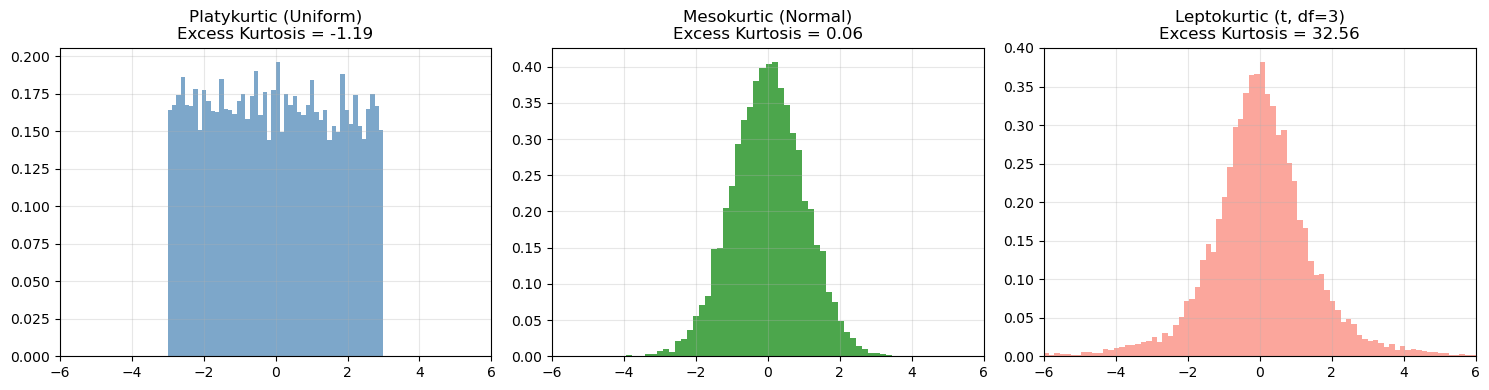

In [32]:
# Demonstrate different kurtosis
np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Platykurtic (light tails) - Uniform
data_platy = np.random.uniform(-3, 3, 10000)
axes[0].hist(data_platy, bins=50, density=True, alpha=0.7, color='steelblue')
axes[0].set_title(f'Platykurtic (Uniform)\nExcess Kurtosis = {stats.kurtosis(data_platy):.2f}')

# Mesokurtic (normal tails) - Normal
data_meso = np.random.normal(0, 1, 10000)
axes[1].hist(data_meso, bins=50, density=True, alpha=0.7, color='green')
axes[1].set_title(f'Mesokurtic (Normal)\nExcess Kurtosis = {stats.kurtosis(data_meso):.2f}')

# Leptokurtic (heavy tails) - t-distribution
data_lepto = stats.t.rvs(df=3, size=10000)
axes[2].hist(data_lepto, bins=80, density=True, alpha=0.7, color='salmon', range=(-6, 6))
axes[2].set_title(f'Leptokurtic (t, df=3)\nExcess Kurtosis = {stats.kurtosis(data_lepto):.2f}')

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-6, 6)
plt.tight_layout()
plt.show()

### Moment Generating Functions (MGFs)

The **moment generating function** of a random variable $X$ is:

$$M_X(t) = E[e^{tX}]$$

**Why are MGFs useful?**

The $n$-th moment can be obtained by differentiating the MGF and evaluating at $t = 0$:

$$E[X^n] = M_X^{(n)}(0) = \left. \frac{d^n}{dt^n} M_X(t) \right|_{t=0}$$

**Key property:** If $M_X(t)$ exists, it **uniquely** determines the distribution of $X$.

### MGFs of Key Distributions

| Distribution | MGF $M_X(t)$ |
|---|---|
| Bernoulli($p$) | $(1-p) + pe^t$ |
| Binomial($n, p$) | $((1-p) + pe^t)^n$ |
| Poisson($\lambda$) | $e^{\lambda(e^t - 1)}$ |
| Normal($\mu, \sigma^2$) | $e^{\mu t + \sigma^2 t^2/2}$ |
| Exponential($\lambda$) | $\frac{\lambda}{\lambda - t}$, for $t < \lambda$ |

In [33]:
# Verify MGF: derive moments of Normal(mu, sigma^2)
# MGF: M(t) = exp(mu*t + sigma^2*t^2/2)
# M'(t) = (mu + sigma^2*t) * M(t)
# M'(0) = mu * 1 = mu  -->  E[X] = mu
# M''(t) = sigma^2 * M(t) + (mu + sigma^2*t)^2 * M(t)
# M''(0) = sigma^2 + mu^2  -->  E[X^2] = sigma^2 + mu^2
# Var(X) = E[X^2] - (E[X])^2 = sigma^2 + mu^2 - mu^2 = sigma^2

mu, sigma = 5, 2
print(f"Normal(\u03bc={mu}, \u03c3={sigma}) - Deriving moments from MGF:")
print(f"  M(t) = exp({mu}t + {sigma**2}t\u00b2/2)")
print(f"  E[X] = M'(0) = \u03bc = {mu}")
print(f"  E[X\u00b2] = M''(0) = \u03c3\u00b2 + \u03bc\u00b2 = {sigma**2} + {mu**2} = {sigma**2 + mu**2}")
print(f"  Var(X) = E[X\u00b2] - (E[X])\u00b2 = {sigma**2 + mu**2} - {mu**2} = {sigma**2}")

# Verify numerically
np.random.seed(42)
samples = np.random.normal(mu, sigma, 1000000)
print(f"\nNumerical verification ({len(samples)} samples):")
print(f"  Sample mean: {np.mean(samples):.4f} (theoretical: {mu})")
print(f"  Sample variance: {np.var(samples, ddof=1):.4f} (theoretical: {sigma**2})")

Normal(μ=5, σ=2) - Deriving moments from MGF:
  M(t) = exp(5t + 4t²/2)
  E[X] = M'(0) = μ = 5
  E[X²] = M''(0) = σ² + μ² = 4 + 25 = 29
  Var(X) = E[X²] - (E[X])² = 29 - 25 = 4

Numerical verification (1000000 samples):
  Sample mean: 4.9968 (theoretical: 5)
  Sample variance: 4.0015 (theoretical: 4)


### Summary Table of Key Distributions

| Distribution | Parameters | Mean $E[X]$ | Variance $Var(X)$ | Support |
|---|---|---|---|---|
| Bernoulli | $p$ | $p$ | $p(1-p)$ | $\{0, 1\}$ |
| Binomial | $n, p$ | $np$ | $np(1-p)$ | $\{0, 1, \ldots, n\}$ |
| Poisson | $\lambda$ | $\lambda$ | $\lambda$ | $\{0, 1, 2, \ldots\}$ |
| Geometric | $p$ | $1/p$ | $(1-p)/p^2$ | $\{1, 2, 3, \ldots\}$ |
| Uniform | $a, b$ | $(a+b)/2$ | $(b-a)^2/12$ | $[a, b]$ |
| Normal | $\mu, \sigma^2$ | $\mu$ | $\sigma^2$ | $(-\infty, \infty)$ |
| Exponential | $\lambda$ | $1/\lambda$ | $1/\lambda^2$ | $[0, \infty)$ |

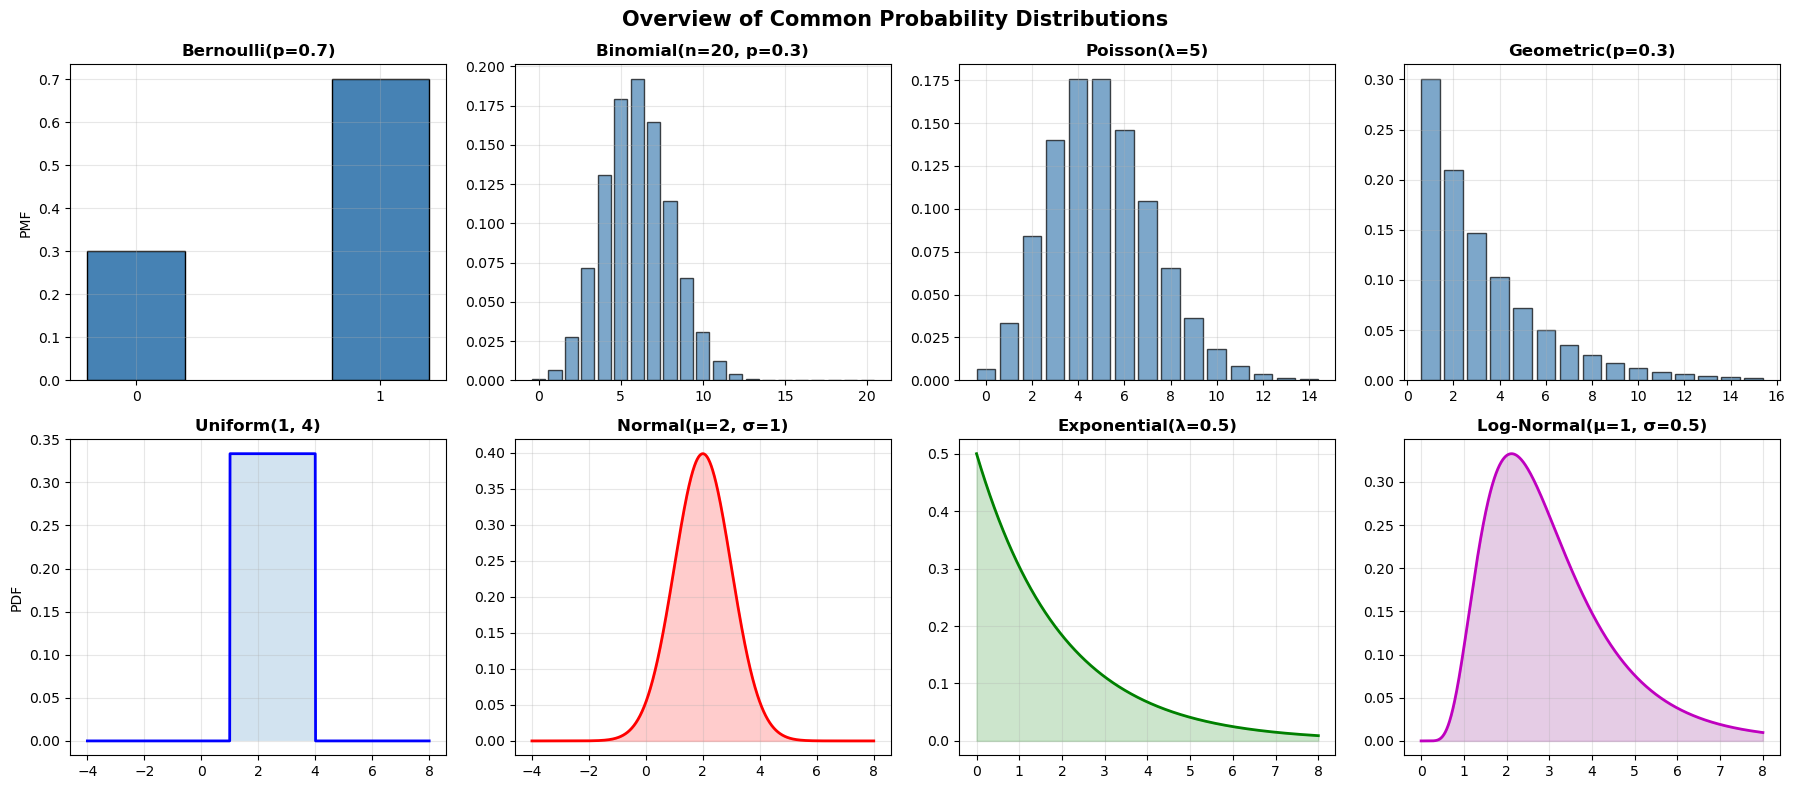

In [34]:
# Comprehensive comparison: all distributions in one figure
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Row 1: Discrete distributions
# Bernoulli
axes[0, 0].bar([0, 1], [0.3, 0.7], color='steelblue', edgecolor='black', width=0.4)
axes[0, 0].set_title('Bernoulli(p=0.7)', fontweight='bold')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_ylabel('PMF')

# Binomial
x_binom = np.arange(0, 21)
axes[0, 1].bar(x_binom, stats.binom.pmf(x_binom, 20, 0.3), 
               color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Binomial(n=20, p=0.3)', fontweight='bold')

# Poisson
x_pois = np.arange(0, 15)
axes[0, 2].bar(x_pois, stats.poisson.pmf(x_pois, 5), 
               color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Poisson(\u03bb=5)', fontweight='bold')

# Geometric
x_geo = np.arange(1, 16)
axes[0, 3].bar(x_geo, stats.geom.pmf(x_geo, 0.3), 
               color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 3].set_title('Geometric(p=0.3)', fontweight='bold')

# Row 2: Continuous distributions
x_cont = np.linspace(-4, 8, 1000)

# Uniform
axes[1, 0].plot(x_cont, stats.uniform.pdf(x_cont, 1, 3), 'b-', linewidth=2)
axes[1, 0].fill_between(x_cont, stats.uniform.pdf(x_cont, 1, 3), alpha=0.2)
axes[1, 0].set_title('Uniform(1, 4)', fontweight='bold')
axes[1, 0].set_ylabel('PDF')

# Normal
axes[1, 1].plot(x_cont, stats.norm.pdf(x_cont, 2, 1), 'r-', linewidth=2)
axes[1, 1].fill_between(x_cont, stats.norm.pdf(x_cont, 2, 1), alpha=0.2, color='red')
axes[1, 1].set_title('Normal(\u03bc=2, \u03c3=1)', fontweight='bold')

# Exponential
x_pos = np.linspace(0, 8, 1000)
axes[1, 2].plot(x_pos, stats.expon.pdf(x_pos, scale=2), 'g-', linewidth=2)
axes[1, 2].fill_between(x_pos, stats.expon.pdf(x_pos, scale=2), alpha=0.2, color='green')
axes[1, 2].set_title('Exponential(\u03bb=0.5)', fontweight='bold')

# Log-Normal
axes[1, 3].plot(x_pos, stats.lognorm.pdf(x_pos, s=0.5, scale=np.exp(1)), 'm-', linewidth=2)
axes[1, 3].fill_between(x_pos, stats.lognorm.pdf(x_pos, s=0.5, scale=np.exp(1)), alpha=0.2, color='purple')
axes[1, 3].set_title('Log-Normal(\u03bc=1, \u03c3=0.5)', fontweight='bold')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.suptitle('Overview of Common Probability Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

#
#
#
 
[
Q
U
I
C
K
]
 
E
n
g
i
n
e
e
r
i
n
g
 
A
p
p
l
i
c
a
t
i
o
n
:
 
C
h
o
o
s
i
n
g
 
t
h
e
 
R
i
g
h
t
 
D
i
s
t
r
i
b
u
t
i
o
n


|
 
S
c
e
n
a
r
i
o
 
|
 
R
e
c
o
m
m
e
n
d
e
d
 
D
i
s
t
r
i
b
u
t
i
o
n
 
|
 
R
e
a
s
o
n
i
n
g
 
|

|
-
-
-
|
-
-
-
|
-
-
-
|

|
 
P
a
s
s
/
f
a
i
l
 
o
f
 
a
 
s
i
n
g
l
e
 
i
n
s
p
e
c
t
i
o
n
 
|
 
B
e
r
n
o
u
l
l
i
 
|
 
T
w
o
 
o
u
t
c
o
m
e
s
 
|

|
 
N
u
m
b
e
r
 
o
f
 
d
e
f
e
c
t
i
v
e
 
w
e
l
d
s
 
i
n
 
5
0
 
i
n
s
p
e
c
t
i
o
n
s
 
|
 
B
i
n
o
m
i
a
l
 
|
 
F
i
x
e
d
 
$
n
$
 
t
r
i
a
l
s
,
 
b
i
n
a
r
y
 
o
u
t
c
o
m
e
 
|

|
 
N
u
m
b
e
r
 
o
f
 
c
r
a
c
k
s
 
p
e
r
 
k
m
 
o
f
 
r
o
a
d
 
|
 
P
o
i
s
s
o
n
 
|
 
C
o
u
n
t
i
n
g
 
r
a
r
e
 
e
v
e
n
t
s
 
|

|
 
T
r
i
a
l
s
 
u
n
t
i
l
 
f
i
r
s
t
 
e
q
u
i
p
m
e
n
t
 
f
a
i
l
u
r
e
 
|
 
G
e
o
m
e
t
r
i
c
 
|
 
W
a
i
t
i
n
g
 
f
o
r
 
f
i
r
s
t
 
s
u
c
c
e
s
s
 
|

|
 
M
a
t
e
r
i
a
l
 
s
t
r
e
n
g
t
h
 
m
e
a
s
u
r
e
m
e
n
t
s
 
|
 
N
o
r
m
a
l
 
|
 
C
L
T
,
 
s
y
m
m
e
t
r
i
c
 
e
r
r
o
r
s
 
|

|
 
T
i
m
e
 
b
e
t
w
e
e
n
 
e
a
r
t
h
q
u
a
k
e
 
e
v
e
n
t
s
 
|
 
E
x
p
o
n
e
n
t
i
a
l
 
|
 
M
e
m
o
r
y
l
e
s
s
 
w
a
i
t
i
n
g
 
t
i
m
e
 
|

|
 
A
r
r
i
v
a
l
 
t
i
m
e
 
w
i
t
h
i
n
 
a
 
s
i
g
n
a
l
 
c
y
c
l
e
 
|
 
U
n
i
f
o
r
m
 
|
 
E
q
u
a
l
l
y
 
l
i
k
e
l
y
 
w
i
t
h
i
n
 
i
n
t
e
r
v
a
l
 
|

---
## 7. Conclusion and Summary

### What We Covered Today

**1. Descriptive Statistics**
- Measures of central tendency (mean, median, mode)
- Measures of spread (range, variance, standard deviation, IQR)
- Shape measures (skewness, kurtosis)
- Data visualization (histograms, boxplots)

**2. Probability Review**
- Sample spaces, events, and probability axioms
- Conditional probability and independence
- Law of total probability and Bayes' theorem

**3. Discrete Random Variables and Distributions**
- PMF and CDF
- Bernoulli, Binomial, Poisson, and Geometric distributions

**4. Expectation and Variance Concepts**
- Expected value and linearity of expectation
- LOTUS (Law of the Unconscious Statistician)
- Variance and its properties

**5. Continuous Random Variables and Distributions**
- PDF and CDF
- Uniform, Normal, and Exponential distributions
- The 68-95-99.7 rule

**6. Moments and Summary Measures**
- Raw and central moments
- Skewness and kurtosis
- Moment generating functions

### Key Takeaways

> **Key Insight: Core Messages**
> 1. **Statistical methods** provide tools to understand and quantify uncertainty in engineering
> 2. **Choose appropriate distributions** based on the problem context (discrete vs. continuous, bounded vs. unbounded, symmetric vs. skewed)
> 3. **Expectation and variance** are the two most fundamental summary statistics for any random variable
> 4. **Moment generating functions** provide a powerful technique for deriving moments and proving distribution relationships

### Engineering Applications

| Area | Statistical Tool |
|---|---|
| **Reliability analysis** | Exponential, Weibull distributions |
| **Quality control** | Binomial, Normal distributions |
| **Risk assessment** | Bayes' theorem, probability models |
| **Data-driven modeling** | Descriptive statistics, distribution fitting |

### What's Next?

In the coming weeks, we will build on these foundations:

- **Joint distributions** and covariance
- **Sampling distributions** and the Central Limit Theorem
- **Hypothesis testing** and confidence intervals
- **Regression analysis**

These topics connect directly to data-driven decision making in civil engineering practice.

---

**Next: Week 06 - Introduction to Machine Learning**